# 3. Forward curve and PCA

Use **all listed FOMC contracts** (not just the front month) to build a multi-meeting implied forward curve, then decompose its daily changes with PCA.

Each later contract is treated as a marginal rate shift relative to the previous meeting. Expected terminal rates are recovered by summing expected shifts. PCA on those forwards is compared with the Litterman–Scheinkman Level / Slope / Curvature factors.

Reads `polymarket_fed_predictions_parsed_uncleaned.csv`.

In [1]:
import requests
import pandas as pd
import time
import json
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import minimize


In [6]:
df=pd.read_csv("polymarket_fed_predictions_parsed_uncleaned.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.loc[df['Date'] == '2024-08-11']

,Event_Slug,Target_Month,Target_Year,Option,Date,Implied_Probability,Actual_Fed_Rate,Rate_Shift,Bin_Type,Implied_Fed_Rate_Target
1436,fed-interest-rates-december-2024,December,2024,75+ bps decrease,2024-08-11,0.0700,5.5,-0.75,Lower_Bound,4.75
1437,fed-interest-rates-december-2024,December,2024,50 bps decrease,2024-08-11,0.1150,5.5,-0.50,Exact_Bin,5.00
1438,fed-interest-rates-december-2024,December,2024,25 bps decrease,2024-08-11,0.6100,5.5,-0.25,Exact_Bin,5.25
1439,fed-interest-rates-december-2024,December,2024,No Change,2024-08-11,0.1750,5.5,0.00,Exact_Bin,5.50
1440,fed-interest-rates-december-2024,December,2024,25+ bps increase,2024-08-11,0.0515,5.5,0.25,Upper_Bound,5.75
2962,fed-interest-rates-november-2024,November,2024,25+ bps increase,2024-08-11,0.0060,5.5,0.25,Upper_Bound,5.75
2963,fed-interest-rates-november-2024,November,2024,75+ bps decrease,2024-08-11,0.0850,5.5,-0.75,Lower_Bound,4.75
2964,fed-interest-rates-november-2024,November,2024,No Change,2024-08-11,0.1500,5.5,0.00,Exact_Bin,5.50
2965,fed-interest-rates-november-2024,November,2024,50 bps decrease,2024-08-11,0.3050,5.5,-0.50,Exact_Bin,5.00
2966,fed-interest-rates-november-2024,November,2024,25 bps decrease,2024-08-11,0.4700,5.5,-0.25,Exact_Bin,5.25


In [8]:
meeting_dates = df.groupby('Event_Slug')['Date'].max().reset_index()
meeting_dates.rename(columns={'Date': 'Meeting_Date'}, inplace=True)

# 2. Sort the events chronologically by when the meetings actually happen
meeting_dates.sort_values('Meeting_Date', inplace=True)
df=pd.merge(df,meeting_dates,on='Event_Slug',how='left')

## Fit Gaussian distributions across successive FOMC contracts

In [9]:
rule_cutoff_date = pd.to_datetime('2025-03-19')
def get_shift_bounds(row):
    """
    Calculates the bounds of the pure expected marginal shift (Delta R).
    FIX 1: Rule check based strictly on the Target Meeting Date.
    """
    shift = row['Rate_Shift']
    
    proxy_date = pd.to_datetime(
        f"{str(row['Target_Year'])}-{str(row['Target_Month'])}-01", 
        format='%Y-%B-%d', 
        errors='coerce'
    )
    is_new_rules = proxy_date >= rule_cutoff_date
    
    if is_new_rules:
        # --- NEW RULES ---
        half_step = 0.125
        if row['Bin_Type'] == 'Lower_Bound': return (-np.inf, shift + half_step)
        elif row['Bin_Type'] == 'Upper_Bound': return (shift - half_step, np.inf)
        else: return (shift - half_step, shift + half_step)
                
    else:
            # --- OLD RULES ---
            eps = 0.0625 
            if shift == 0: return (-eps, eps)
            elif shift < 0: 
                if row['Bin_Type'] == 'Lower_Bound': return (-np.inf, shift - eps)
                else: return (shift - eps, shift + 0.25 - eps)
            elif shift > 0: 
                # FIX: Start exactly where the "No Change" bin ends
                if row['Bin_Type'] == 'Upper_Bound': return (eps, np.inf) 
                else: return (shift - 0.25 + eps, shift + eps)

In [10]:
df['Shift_Bounds'] = df.apply(get_shift_bounds, axis=1)

In [11]:
df_forward = df.copy()
df_forward = df_forward.loc[df_forward['Date']>='2024-08-01']

In [12]:
from scipy.stats import norm
from scipy.optimize import minimize

def fit_distribution_cdf_shifts(bounds, market_probs):
    def loss_function(params):
        mu, sigma = params
        theoretical_probs = []
        for lower, upper in bounds:
            p_upper = norm.cdf(upper, loc=mu, scale=sigma)
            p_lower = norm.cdf(lower, loc=mu, scale=sigma)
            theoretical_probs.append(p_upper - p_lower)
        return np.sum((np.array(theoretical_probs) - market_probs)**2)

    # Heuristic guess using the pure shift bounds
    rough_centers = [np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds]
    guess_mu = np.sum(np.array(rough_centers) * market_probs)
    
    # Estimate variance to give sigma a smart starting point
    variance = np.sum(market_probs * (np.array(rough_centers) - guess_mu)**2)
    guess_sigma = max(np.sqrt(variance), 0.1) 

    # Guardrails: Don't let mu wander more than 75 bps away from common sense
    bnds = ((guess_mu - 0.75, guess_mu + 0.75), (0.01, 2.0))

    result = minimize(loss_function, x0=[guess_mu, guess_sigma], method='L-BFGS-B', bounds=bnds)
    
    # Check if successful and guardrails
    if result.success and abs(result.x[0] - guess_mu) < 0.74:
        return result.x[0], result.x[1]
    return np.nan, np.nan




In [13]:
# df_forward = df.copy()

# Pre-calculate all bounds


daily_params = []
unique_dates = df_forward['Date'].sort_values().unique()

print(f"Processing {len(unique_dates)} days of market data across multiple events...")

for date in unique_dates:
    day_data = df_forward[df_forward['Date'] == date].copy()
    unique_events = day_data['Event_Slug'].unique()
    
    # Because there are multiple contracts trading today, we must loop through each one
    for event in unique_events:
        event_data = day_data[day_data['Event_Slug'] == event].copy()
        
        if len(event_data) < 2:
            continue
            
        raw_probs = event_data['Implied_Probability'].values
        probs = raw_probs / np.sum(raw_probs) 
        bounds = event_data['Shift_Bounds'].tolist()
        
        # Optimize for the pure shift
        mu, sigma = fit_distribution_cdf_shifts(bounds, probs)
        
        # Fallback Mechanism (Now correctly bound to the shift limits)
        if np.isnan(mu) or np.isnan(sigma):
            centers = np.array([np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds])
            mu = np.sum(centers * probs)
            sigma = np.sqrt(np.sum(probs * (centers - mu)**2))
            print(f"Fallback triggered for {event} on {date.date()}: mu={mu:.4f}, sigma={sigma:.4f}")
        
        sigma = max(sigma, 0.08) 
        
        daily_params.append({
            'Date': date, 
            'Event_Slug': event,
            'Target_Year': event_data['Target_Year'].iloc[0],
            'Target_Month': event_data['Target_Month'].iloc[0],
            'Actual_Fed_Rate': event_data['Actual_Fed_Rate'].iloc[0], 
            'raw_shift_mu': mu, 
            'raw_sigma': sigma 
        })

Processing 611 days of market data across multiple events...
Fallback triggered for fed-decision-in-october on 2025-10-30: mu=0.1875, sigma=0.0000
Fallback triggered for fed-decision-in-october on 2025-10-31: mu=0.1875, sigma=0.0000
Fallback triggered for fed-decision-in-april on 2026-03-16: mu=0.1875, sigma=0.0000
Fallback triggered for fed-decision-in-april on 2026-03-19: mu=0.0023, sigma=0.0204


In [15]:
params_df = pd.DataFrame(daily_params)

# We MUST group by Event_Slug before smoothing, otherwise March data gets smoothed into May data
params_df = params_df.sort_values('Date')
params_df['smoothed_shift_mu'] = params_df.groupby('Event_Slug')['raw_shift_mu'].transform(lambda x: x.ewm(span=5, adjust=False).mean())
params_df['smoothed_sigma'] = params_df.groupby('Event_Slug')['raw_sigma'].transform(lambda x: x.ewm(span=5, adjust=False).mean())



params_df['Proxy_Meeting_Date'] = pd.to_datetime(
    params_df['Target_Year'].astype(str) + '-' + params_df['Target_Month'] + '-01', 
    format='%Y-%B-%d', errors='coerce'
)


# Drop Lingering Past Contracts:
# We align the Trading Date to the 1st of the month to safely ensure no cumsum meetings that have already occurred
params_df['Trading_Month_Start'] = pd.to_datetime(params_df['Date']).dt.to_period('M').dt.to_timestamp()
params_df = params_df[params_df['Proxy_Meeting_Date'] >= params_df['Trading_Month_Start']]

params_df = params_df.drop_duplicates(subset=['Date', 'Proxy_Meeting_Date'], keep='last')

params_df = params_df.sort_values(by=['Date', 'Proxy_Meeting_Date'])

params_df['Cumulative_Expected_Change'] = params_df.groupby('Date')['smoothed_shift_mu'].cumsum()

# Calculate Absolute Target Rate: R_0 + Cumsum(Delta R)
params_df['Expected_Absolute_Rate'] = params_df['Actual_Fed_Rate'] + params_df['Cumulative_Expected_Change']


sample_date = params_df['Date'].iloc[-1] 
display_cols = ['Date', 'Event_Slug', 'Target_Month', 'Actual_Fed_Rate', 'smoothed_shift_mu', 'Expected_Absolute_Rate']
print(params_df[params_df['Date'] == sample_date][display_cols].to_string(index=False))

      Date            Event_Slug Target_Month  Actual_Fed_Rate  smoothed_shift_mu  Expected_Absolute_Rate
2026-04-03 fed-decision-in-april        April             3.75          -0.059399                3.690601


In [17]:
test= params_df.loc[params_df['Event_Slug']=="fed-interest-rates-december-2024"]

(array([19936., 19950., 19967., 19981., 19997., 20011., 20028., 20042.,
        20058., 20072.]),
 [Text(19936.0, 0, '2024-08-01'),
  Text(19950.0, 0, '2024-08-15'),
  Text(19967.0, 0, '2024-09-01'),
  Text(19981.0, 0, '2024-09-15'),
  Text(19997.0, 0, '2024-10-01'),
  Text(20011.0, 0, '2024-10-15'),
  Text(20028.0, 0, '2024-11-01'),
  Text(20042.0, 0, '2024-11-15'),
  Text(20058.0, 0, '2024-12-01'),
  Text(20072.0, 0, '2024-12-15')])

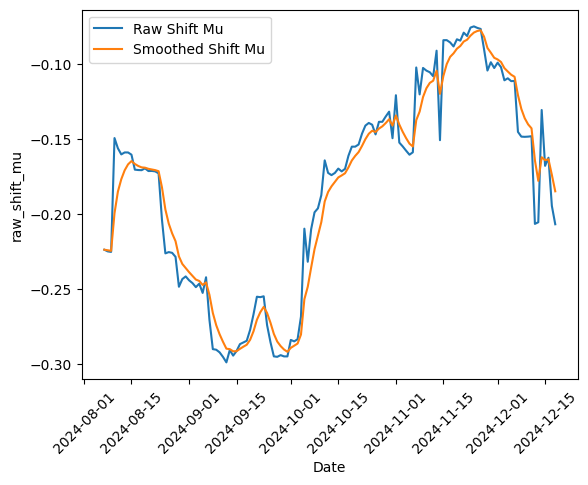

In [18]:

sns.lineplot(data=test, x='Date', y='raw_shift_mu', label='Raw Shift Mu')
sns.lineplot(data=test, x='Date', y='smoothed_shift_mu', label='Smoothed Shift Mu')

plt.xticks(rotation=45)

In [21]:
def debug_forward_curve_day(df, debug_date):
    """
    Isolates a single trading day to reveal exactly what cumsum() is adding.
    """
    
    # isolate day
    day_df = df[df['Date'] == pd.to_datetime(debug_date)].copy()
    
    if day_df.empty:
        print("No data found for this date. Check your date format!")
        return
        
    base_rate = day_df['Actual_Fed_Rate'].iloc[0]
    print(f"BASELINE: Actual Fed Rate on this day = {base_rate}%\n")
    
    day_df = day_df.sort_values('Proxy_Meeting_Date')
    
    # Display the exact step-by-step math
    debug_cols = [
        'Event_Slug', 
        'Target_Month',
        'raw_shift_mu', 
        'smoothed_shift_mu', 
        'Cumulative_Expected_Change', 
        'Expected_Absolute_Rate'
    ]
    
    print(day_df[debug_cols].to_string(index=False))

debug_forward_curve_day(params_df, '2025-03-18')

BASELINE: Actual Fed Rate on this day = 4.5%

              Event_Slug Target_Month  raw_shift_mu  smoothed_shift_mu  Cumulative_Expected_Change  Expected_Absolute_Rate
   fed-decision-in-march        March     -0.000549          -0.000719                   -0.000719                4.499281
fed-decision-in-may-2025          May     -0.056295          -0.071997                   -0.072717                4.427283
    fed-decision-in-june         June     -0.147713          -0.159236                   -0.231952                4.268048


In [ ]:
import plotly.express as px

def plot_forward_time_series(df):
    """
    Plots the expected absolute rate for each future meeting over time.
    """
    # Create a clean label for the legend
    df['Meeting_Label'] = df['Target_Month'] + ' ' + df['Target_Year'].astype(str)
    
    plot_df = df.dropna(subset=['Expected_Absolute_Rate'])

    fig = px.line(
        plot_df, 
        x='Date', 
        y='Expected_Absolute_Rate', 
        color='Meeting_Label',
        title='Evolution of Implied Fed Funds Forward Rates',
        labels={
            'Expected_Absolute_Rate': 'Implied Target Rate (%)',
            'Date': 'Trading Date',
            'Meeting_Label': 'FOMC Meeting'
        }
    )

    fig.add_scatter(
            x=plot_df['Date'], 
            y=plot_df['Actual_Fed_Rate'], 
            name='Actual Fed Rate',
            line=dict(color='black', width=3, dash='dash'), # Distinct style
            hovertemplate='Actual Fed Rate: %{y:.2f}%<extra></extra>'
        )
    
    fig.update_layout(
        template='plotly_white',
        hovermode='x unified', # Shows all rates simultaneously when you hover over a specific day
        yaxis_tickformat='.2f',
        legend_title_text='Target Meeting'
    )
    
    fig.show(render='browser')

plot_forward_time_series(params_df)

In [63]:
params_df['Event_Slug'].unique()

array(['fed-interest-rates-september-2024',
       'fed-interest-rates-november-2024',
       'fed-interest-rates-december-2024',
       'fed-interest-rates-january-2025', 'fed-decision-in-march',
       'fed-decision-in-may-2025', 'fed-decision-in-june',
       'fed-decision-in-july', 'fed-decision-in-september',
       'fed-decision-in-october', 'fed-decision-in-december',
       'fed-decision-in-january', 'fed-decision-in-april'], dtype=object)

## PCA of the implied forward curve


In [23]:
from sklearn.decomposition import PCA

In [ ]:
def prepare_curve_for_pca(df):
    # sort strictly by Trading Date and chronological Meeting Date
    df_sorted = df.sort_values(['Date', 'Proxy_Meeting_Date']).copy()
    
    # Assign dynamic tenors (T1 = Front Month, T2 = Next Month...
    df_sorted['Tenor_Index'] = df_sorted.groupby('Date').cumcount() + 1
    df_sorted['Tenor_Label'] = 'T' + df_sorted['Tenor_Index'].astype(str)
    
    wide_df = df_sorted.pivot(index='Date', columns='Tenor_Label', values='Expected_Absolute_Rate')
    
    # keep only T1, T2, T3 (dropping days with no 3 active forward contracts)
    wide_df = wide_df[['T1', 'T2', 'T3']].dropna()
    
    daily_changes_bps = wide_df.diff().dropna() * 100
    
    return daily_changes_bps

daily_curve_changes = prepare_curve_for_pca(params_df)

In [25]:
def prepare_curve_for_pca(df):
    
    df_sorted = df.sort_values(['Date', 'Proxy_Meeting_Date']).copy()
    
    df_sorted['Tenor_Index'] = df_sorted.groupby('Date').cumcount() + 1
    df_sorted['Tenor_Label'] = 'T' + df_sorted['Tenor_Index'].astype(str)
    
    wide_df = df_sorted.pivot(index='Date', columns='Tenor_Label', values='Expected_Absolute_Rate')
    
    # Safely ensure T1, T2, T3 exist in the columns
    for t in ['T1', 'T2', 'T3']:
        if t not in wide_df.columns:
            wide_df[t] = np.nan
    wide_df = wide_df[['T1', 'T2', 'T3']]
    
    # bufixing
    wide_df = wide_df.asfreq('D')
    
    # 2. Forward Fill missing rates. 
    # We set limit=7 so we safely bridge short post-meeting gaps, 
    # but we don't accidentally carry stale data across a 2-month dead period.
    wide_df_filled = wide_df.fillna(method='ffill', limit=7)
    
    #calculate the Daily Difference (in Basis Points) ON THE CONTINUOUS TIMELINE
    daily_changes_bps = wide_df_filled.diff() * 100
    
    daily_changes_bps = daily_changes_bps.dropna()
    
    
    return daily_changes_bps

daily_curve_changes = prepare_curve_for_pca(params_df)

C:\Users\steph\AppData\Local\Temp\ipykernel_46492\3102154530.py:22: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [26]:
def prepare_curve_for_pca_robust(df):
    print("Preparing robust Constant Maturity changes...")
    
    df = df.sort_values(['Date', 'Proxy_Meeting_Date']).copy()
    
    df['Daily_Change_Bps'] = df.groupby('Event_Slug')['Expected_Absolute_Rate'].diff() * 100
    
    # Asign the Tenor tags (T1, T2, T3) based on chronological order
    df['Tenor_Index'] = df.groupby('Date').cumcount() + 1
    df['Tenor_Label'] = 'T' + df['Tenor_Index'].astype(str)
    
    # pivot daily changes
    wide_changes = df.pivot(index='Date', columns='Tenor_Label', values='Daily_Change_Bps')
    
    # Safely ensure T1, T2, T3 exist
    for t in ['T1', 'T2', 'T3']:
        if t not in wide_changes.columns:
            wide_changes[t] = np.nan
    wide_changes = wide_changes[['T1', 'T2', 'T3']]
    
    # hndle the Gaps
    clean_changes = wide_changes.fillna(0.0)
    
    clean_changes = clean_changes.iloc[1:]
    
    return clean_changes

daily_curve_changes = prepare_curve_for_pca_robust(params_df)

Preparing robust Constant Maturity changes...


<Axes: xlabel='Date'>

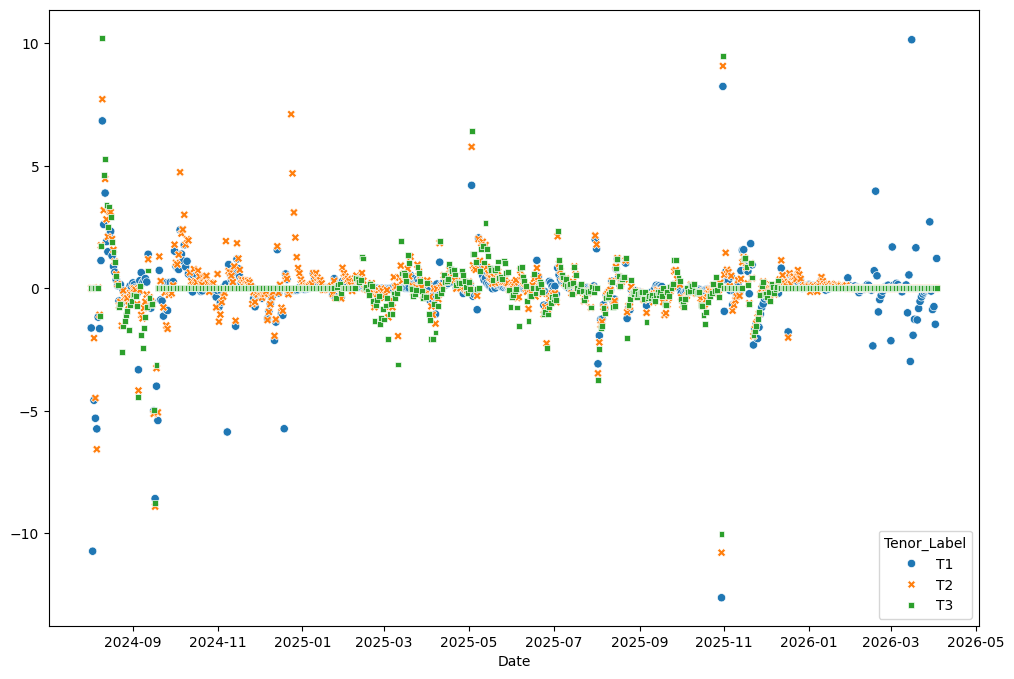

In [27]:
plt.figure(figsize=(12, 8))
sns.scatterplot(daily_curve_changes)

In [28]:
# PCA ( for 3 components)
pca = PCA(n_components=3)
pca.fit(daily_curve_changes)

explained_variance = pca.explained_variance_ratio_ * 100

print(f"Variance Explained by PC1 (Level):     {explained_variance[0]:.2f}%")
print(f"Variance Explained by PC2 (Slope):     {explained_variance[1]:.2f}%")
print(f"Variance Explained by PC3 (Curvature): {explained_variance[2]:.2f}%")
print(f"Total Variance Explained:              {np.sum(explained_variance):.2f}%")


loadings = pd.DataFrame(
    pca.components_, 
    columns=['T1 (Front)', 'T2 (Next)', 'T3 (Future)'], 
    index=['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
)

Variance Explained by PC1 (Level):     80.94%
Variance Explained by PC2 (Slope):     13.21%
Variance Explained by PC3 (Curvature): 5.85%
Total Variance Explained:              100.00%


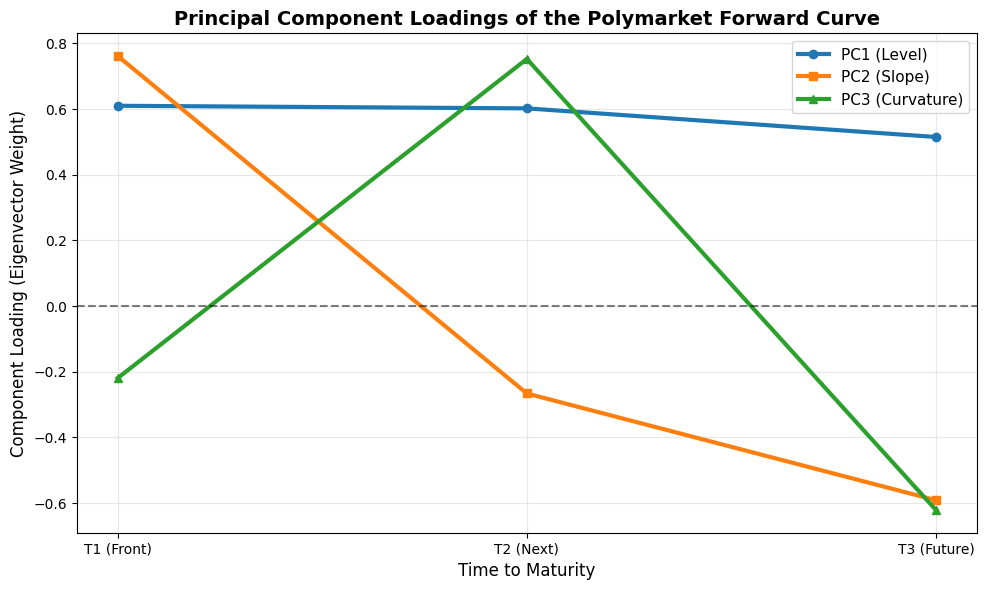

In [29]:
def plot_pca_loadings(loadings_df):
    plt.figure(figsize=(10, 6))
    plt.plot(loadings_df.columns, loadings_df.loc['PC1 (Level)'], marker='o', linewidth=3, label='PC1 (Level)')
    plt.plot(loadings_df.columns, loadings_df.loc['PC2 (Slope)'], marker='s', linewidth=3, label='PC2 (Slope)')
    plt.plot(loadings_df.columns, loadings_df.loc['PC3 (Curvature)'], marker='^', linewidth=3, label='PC3 (Curvature)')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title('Principal Component Loadings of the Polymarket Forward Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Time to Maturity', fontsize=12)
    plt.ylabel('Component Loading (Eigenvector Weight)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_pca_loadings(loadings)